In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# Фильтрация языков

Нам нужны только языки с неполным инвентарём взрывных. Потенциально эти языки можно найти среди тех, у которых в целом не очень большой инвентарь, поэтому мы скачали таблицу из WALS и отфильтровали языки с маленьким инвентарём в качестве потенциальных кандидатов.

In [28]:
df = pd.read_csv('typology.tsv', sep='\t')
df.sample(10)

,wals code,name,value,description,latitude,longitude,genus,family,area
115,dgr,Dagur,3,Average,48.000000,124.000000,Mongolic,Altaic,Phonology
76,bul,Bulgarian,3,Average,42.500000,25.000000,Slavic,Indo-European,Phonology
538,yan,Yana,3,Average,40.500000,-122.000000,Yana,Hokan,Phonology
523,war,Wari',2,Moderately small,-11.333333,-65.000000,Chapacura-Wanham,Chapacura-Wanham,Phonology
72,bra,Brao,3,Average,14.166667,107.500000,Bahnaric,Austro-Asiatic,Phonology
447,shk,Shipibo-Konibo,2,Moderately small,-7.500000,-75.000000,Panoan,Pano-Tacanan,Phonology
498,tso,Tsou,2,Moderately small,23.500000,120.750000,Tsou,Austronesian,Phonology
129,der,Dla (Proper),1,Small,-3.583333,141.000000,Senagi,Senagi,Phonology
136,eja,Ejagham,3,Average,5.416667,8.666667,Ekoid-Mbe,Niger-Congo,Phonology
42,ava,Avar,5,Large,42.500000,46.500000,Avar-Andic-Tsezic,Nakh-Daghestanian,Phonology


In [29]:
df_filtered = df[df['description'].str.contains('small', case=False, na=False)]
df_filtered[['name', 'description']]

,name,description
2,Abipón,Moderately small
4,Achumawi,Moderately small
5,Aché,Small
7,Adzera,Moderately small
11,Ainu,Small
...,...,...
548,Yidiny,Small
549,Yimas,Small
550,Yoruba,Moderately small
553,Yucuna,Moderately small


In [30]:
df_filtered.to_csv('small_typology.tsv', sep='\t', index=False)

# Баллансировка выборки

In [2]:
our_data = pd.read_csv('our_data.csv')
our_data = our_data.drop(columns=['литература', 'комментарии'])
our_data

,язык,семья,ареал,p,t,k,b,d,g,сколько взрывных фонем
0,Abau,Sepik,Papunesia,1,0,1,0,0,0,2
1,Abenaki (Western),Algic,North America,1,1,1,1,1,1,6
2,Abipon,Guaicuru,South America,1,1,1,0,0,0,3
3,Achagua,Arawak,South America,1,1,1,1,1,0,5
4,Achi,Mayan,North America,1,1,1,0,0,0,3
...,...,...,...,...,...,...,...,...,...,...
594,Yukpa (Macoíta),Carib,South America,1,1,1,0,1,0,4
595,Yukulta,Tangkic,Australia,1,1,1,0,0,0,3
596,Yulparija,Pama-Nyungan,Australia,1,1,1,0,0,0,3
597,Yurakaré,Isolate,South America,1,1,1,1,1,0,5


In [ ]:
only_voiceless = (our_data[['p', 't', 'k']].sum(axis=1) > 0) & (our_data[['b', 'd', 'g']].sum(axis=1) == 0)
only_voiced = (our_data[['b', 'd', 'g']].sum(axis=1) > 0) & (our_data[['p', 't', 'k']].sum(axis=1) == 0)

df_filtered = our_data[~(only_voiceless | only_voiced)]
df_filtered = df_filtered[df_filtered['сколько взрывных фонем'] < 6]

print(f"Удалено языков: {len(our_data) - len(df_filtered)}")
df_filtered

Удалено языков: 430


,язык,семья,ареал,p,t,k,b,d,g,сколько взрывных фонем
3,Achagua,Arawak,South America,1,1,1,1,1,0,5
13,Aikanã,Isolate,South America,1,1,1,1,1,0,5
17,Alabama,Muskogean,North America,1,1,1,1,0,0,4
26,Amanab,Border,Papunesia,1,1,1,1,0,1,5
32,Andoke,Isolate,South America,1,1,1,1,1,0,5
...,...,...,...,...,...,...,...,...,...,...
564,Xipaya,Tupí,South America,1,1,1,1,1,0,5
565,Xiriâna,Arawak,South America,1,1,1,1,1,0,5
567,Yaathe,Macro-Ge,South America,1,1,1,0,1,0,4
594,Yukpa (Macoíta),Carib,South America,1,1,1,0,1,0,4


In [5]:
fam_col = 'семья'
area_col = 'ареал'
pairs = df_filtered[[fam_col, area_col]].drop_duplicates().reset_index(drop=True)
num_pairs = len(pairs)
print(f'Unique family-area pairs: {num_pairs}')
pairs_our = df_filtered.groupby([fam_col, area_col]).size().reset_index(name='languages_count').sort_values('languages_count', ascending=False)
pairs_our.to_csv('family_area_pairs_counts_my.csv', index=False)
pairs_our

Unique family-area pairs: 42


,семья,ареал,languages_count
4,Austronesian,Papunesia,28
1,Arawak,South America,17
38,Tupí,South America,15
15,Isolate,South America,10
19,Macro-Ge,South America,8
27,Panoan,South America,8
37,Tucanoan,South America,6
20,Mayan,North America,6
8,Carib,South America,6
36,Trans New Guinea,Papunesia,5


In [6]:
glottolog_df = pd.read_csv('languages.csv')
glottolog_df.head()

,ID,Name,Macroarea,Latitude,Longitude,Glottocode,ISO639P3code,Family_Glottocode,Family_Name
0,kore1280,Korean,Eurasia,37.500000,128.00000,kore1280,kor,kore1284,Koreanic
1,kett1243,Ket,Eurasia,63.755100,87.54660,kett1243,ket,yeni1252,Yeniseian
2,lakk1252,Lak,Eurasia,42.132800,47.08090,lakk1252,lbe,nakh1245,Nakh-Daghestanian
3,kaba1278,Kabardian,Eurasia,43.508200,43.39180,kaba1278,kbd,abkh1242,Abkhaz-Adyge
4,nucl1302,Georgian,Eurasia,41.850397,43.78613,nucl1302,kat,kart1248,Kartvelian


In [7]:
fam_col = 'Family_Name'
area_col = 'Macroarea'
pairs = glottolog_df[[fam_col, area_col]].drop_duplicates().reset_index(drop=True)
num_pairs = len(pairs)
print(f'Unique family-area pairs: {num_pairs}')
pairs_glottolog = glottolog_df.groupby([fam_col, area_col]).size().reset_index(name='languages_count').sort_values('languages_count', ascending=False)
pairs_glottolog.to_csv('family_area_pairs_counts.csv', index=False)
pairs_glottolog

Unique family-area pairs: 200


,Family_Name,Macroarea,languages_count
11,Atlantic-Congo,Africa,423
133,Pama-Nyungan,Australia,243
71,Indo-European,Eurasia,131
15,Austronesian,Papunesia,107
1,Afro-Asiatic,Africa,100
...,...,...,...
147,Shastan,North America,1
67,Huavean,North America,1
73,Indo-European,Papunesia,1
152,South Bird's Head Family,Papunesia,1


In [8]:
def balance_sample(df_my_full, pairs_counts_glottolog, target_size=100):
    # 1. Считаем глобальные пропорции в Glottolog
    total_glottolog = pairs_counts_glottolog['languages_count'].sum()
    pairs_counts_glottolog['target_prop'] = pairs_counts_glottolog['languages_count'] / total_glottolog
    
    # 2. Рассчитываем квоты для каждой семьи/ареала
    # Округляем до ближайшего целого
    pairs_counts_glottolog['quota'] = (pairs_counts_glottolog['target_prop'] * target_size).round().astype(int)
    
    balanced_list = []
    
    # 3. Итерируемся по каждой группе и отбираем языки
    for _, row in pairs_counts_glottolog.iterrows():
        family = row['Family_Name']
        area = row['Macroarea']
        quota = row['quota']
        
        # Фильтруем языки этой группы в твоей выборке
        subset = df_my_full[(df_my_full['семья'] == family) & (df_my_full['ареал'] == area)]
        
        if len(subset) > 0:
            # Берем либо квоту, либо всё что есть (если квота больше наличия)
            n_to_take = min(len(subset), quota)
            if n_to_take > 0:
                sampled_subset = subset.sample(n=n_to_take, random_state=42) # random_state для воспроизводимости
                balanced_list.append(sampled_subset)
    
    # Собираем всё в одну таблицу
    df_balanced = pd.concat(balanced_list).reset_index(drop=True)
    return df_balanced

In [21]:
df_balanced = balance_sample(pairs_our, pairs_glottolog, target_size=600)
print(f"Размер сбалансированной выборки: {sum(df_balanced['languages_count'])}")
df_balanced

Размер сбалансированной выборки: 64


,семья,ареал,languages_count
0,Austronesian,Papunesia,28
1,Tucanoan,South America,6
2,Uto-Aztecan,North America,1
3,Mayan,North America,6
4,Salishan,North America,1
5,Chibchan,South America,2
6,Sepik,Papunesia,1
7,Austronesian,Eurasia,1
8,Algic,North America,2
9,Arawan,South America,3


In [31]:
quotas_df = df_balanced 
big_sample = df_filtered 

balanced_samples = []

for _, row in quotas_df.iterrows():
    family = row['семья']
    area = row['ареал']
    quota = row['languages_count']

    available = big_sample[(big_sample['семья'] == family) & (big_sample['ареал'] == area)]
    
    if len(available) >= quota:
        sampled = available.sample(n=quota, random_state=42)
    else:
        sampled = available
        print(f"Внимание: для {family} / {area} нужно {quota}, но есть только {len(available)}")
    
    balanced_samples.append(sampled)

df_final = pd.concat(balanced_samples, ignore_index=True)

df_final.to_csv('final_balanced.csv', index=False)

# Анализ данных

In [38]:
df_final = pd.read_csv('final_balanced.csv')
df_final

,язык,семья,ареал,p,t,k,b,d,g,сколько взрывных фонем
0,Itbayat,Austronesian,Papunesia,1,0,1,1,1,1,5
1,Tukang Besi North,Austronesian,Papunesia,1,1,1,1,0,1,5
2,Indonesian Bajau,Austronesian,Papunesia,1,0,1,1,0,1,4
3,Sundanese,Austronesian,Papunesia,1,0,1,1,1,1,5
4,Biak,Austronesian,Papunesia,1,1,1,1,1,0,5
...,...,...,...,...,...,...,...,...,...,...
59,Amanab,Border,Papunesia,1,1,1,1,0,1,5
60,Boruca,Chibchan,North America,0,1,1,1,1,1,5
61,Bribri,Chibchan,North America,1,1,1,1,1,0,5
62,Buglere,Chibchan,North America,0,1,1,1,1,1,5


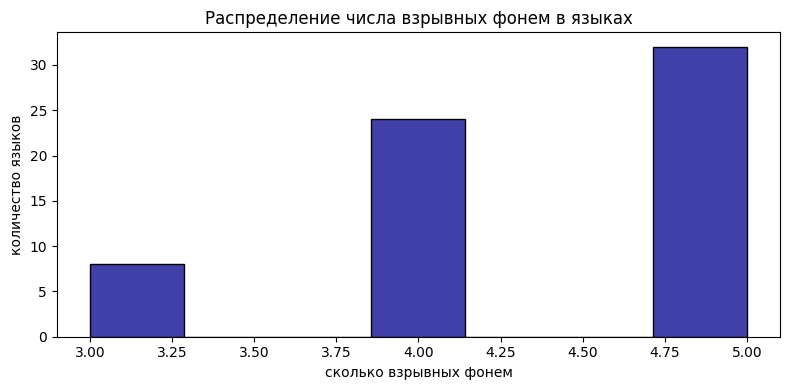

In [39]:
col = 'сколько взрывных фонем'
df_final[col] = pd.to_numeric(df_final[col], errors='coerce')
vals = df_final[col].dropna()
plt.figure(figsize=(8, 4))
sns.histplot(vals, kde=False, color='darkblue')
plt.title('Распределение числа взрывных фонем в языках')
plt.xlabel(col)
plt.ylabel('количество языков')
plt.tight_layout()
plt.show()

,phoneme,count
0,p,50
1,t,47
2,k,62
3,b,59
4,d,36
5,g,26


/var/folders/v3/g9p917f512s52x0xb8r6htn00000gn/T/ipykernel_31462/2222476112.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_counts, x='phoneme', y='count', palette='viridis')


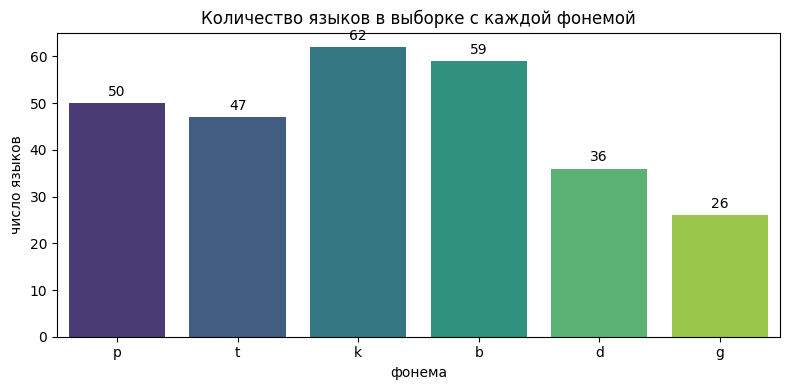

In [35]:
phonemes = ['p','t','k','b','d','g']
# ensure columns exist and are integer 0/1
for ph in phonemes:
    if ph in df_final.columns:
        df_final[ph] = pd.to_numeric(df_final[ph], errors='coerce').fillna(0).astype(int)
    else:
        df_final[ph] = 0
# compute counts
counts = {ph: int(df_final[ph].sum()) for ph in phonemes}
df_counts = pd.DataFrame(list(counts.items()), columns=['phoneme','count'])
display(df_counts)
# plot
plt.figure(figsize=(8,4))
sns.barplot(data=df_counts, x='phoneme', y='count', palette='viridis')
ax = plt.gca()
for p in ax.patches:
    h = int(p.get_height())
    ax.annotate(f'{h}', xy=(p.get_x()+p.get_width()/2, h), xytext=(0,3), textcoords='offset points', ha='center', va='bottom')
plt.title('Количество языков в выборке с каждой фонемой')
plt.xlabel('фонема')
plt.ylabel('число языков')
plt.tight_layout()
plt.show()

In [45]:
df_final

,язык,семья,ареал,p,t,k,b,d,g,сколько взрывных фонем
0,Itbayat,Austronesian,Papunesia,1,0,1,1,1,1,5
1,Tukang Besi North,Austronesian,Papunesia,1,1,1,1,0,1,5
2,Indonesian Bajau,Austronesian,Papunesia,1,0,1,1,0,1,4
3,Sundanese,Austronesian,Papunesia,1,0,1,1,1,1,5
4,Biak,Austronesian,Papunesia,1,1,1,1,1,0,5
...,...,...,...,...,...,...,...,...,...,...
59,Amanab,Border,Papunesia,1,1,1,1,0,1,5
60,Boruca,Chibchan,North America,0,1,1,1,1,1,5
61,Bribri,Chibchan,North America,1,1,1,1,1,0,5
62,Buglere,Chibchan,North America,0,1,1,1,1,1,5


Языки у которых 5 фонем

In [46]:
df_final[df_final['сколько взрывных фонем'] == 5]

,язык,семья,ареал,p,t,k,b,d,g,сколько взрывных фонем
0,Itbayat,Austronesian,Papunesia,1,0,1,1,1,1,5
1,Tukang Besi North,Austronesian,Papunesia,1,1,1,1,0,1,5
3,Sundanese,Austronesian,Papunesia,1,0,1,1,1,1,5
4,Biak,Austronesian,Papunesia,1,1,1,1,1,0,5
5,Ngad''a,Austronesian,Papunesia,1,1,1,1,0,1,5
7,Tausug,Austronesian,Papunesia,1,0,1,1,1,1,5
9,Nias,Austronesian,Papunesia,0,1,1,1,1,1,5
11,Buol,Austronesian,Papunesia,1,0,1,1,1,1,5
12,Cocos Islands Malay,Austronesian,Papunesia,1,0,1,1,1,1,5
14,Central Sama,Austronesian,Papunesia,1,0,1,1,1,1,5


Языки у которых 5 фонем

Отсутствует g: 12

Отсутствует t: 8

Отсутствует p: 6

Отсутствует d: 5

Отсутствует b: 1

Отсутствует k: 0

In [48]:
df_final[df_final['сколько взрывных фонем'] == 4]

,язык,семья,ареал,p,t,k,b,d,g,сколько взрывных фонем
2,Indonesian Bajau,Austronesian,Papunesia,1,0,1,1,0,1,4
6,Roro,Austronesian,Papunesia,1,1,1,1,0,0,4
8,Leti,Austronesian,Papunesia,1,1,1,0,1,0,4
10,Palauan,Austronesian,Papunesia,0,1,1,1,1,0,4
13,Filipino,Austronesian,Papunesia,1,0,1,1,0,1,4
22,Siang,Austronesian,Papunesia,1,1,1,1,0,0,4
25,Paiwan,Austronesian,Papunesia,1,0,1,1,0,1,4
26,Selaru,Austronesian,Papunesia,0,1,1,1,1,0,4
27,Ilocano,Austronesian,Papunesia,1,0,1,1,0,1,4
32,Secoya,Tucanoan,South America,1,1,1,0,1,0,4


Языки у которых 4 фонемы

Отсутствуют td: 4

Отсутствуют dg: 11

Отсутствуют bg: 3

Отсутствуют pg: 4

Отсутствуют kg: 2

In [49]:
df_final[df_final['сколько взрывных фонем'] == 3]

,язык,семья,ареал,p,t,k,b,d,g,сколько взрывных фонем
16,Tetum,Austronesian,Papunesia,1,0,1,1,0,0,3
18,Waima,Austronesian,Papunesia,1,0,1,1,0,0,3
20,Satawalese,Austronesian,Papunesia,1,0,1,0,0,1,3
21,Wogeo,Austronesian,Papunesia,0,0,1,1,0,1,3
34,Kawaiisu,Uto-Aztecan,North America,1,0,1,1,0,0,3
42,Tunebo (Central dialect),Chibchan,South America,0,1,1,1,0,0,3
47,Arapaho,Algic,North America,0,1,1,1,0,0,3
49,Jarawara,Arawan,South America,0,1,1,1,0,0,3
